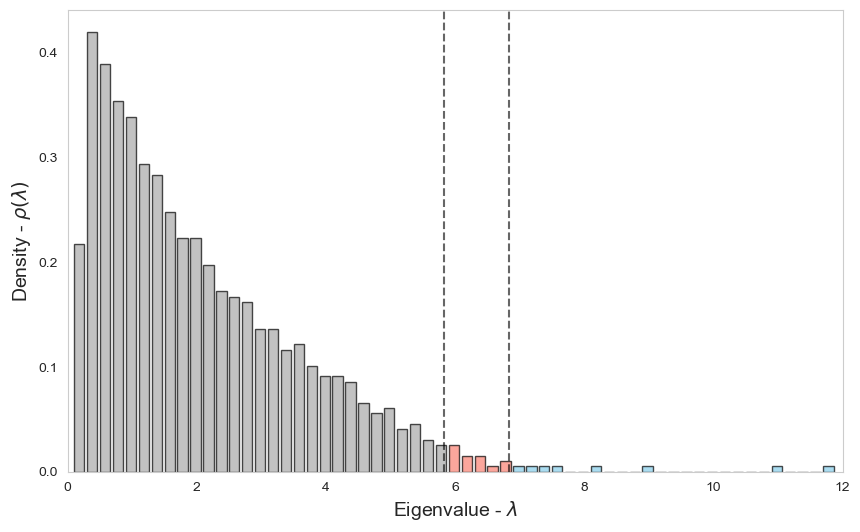

In [6]:
import numpy as np
import matplotlib.pyplot as plt
arr = np.load('ev_data/simulated_pcs.npy')
# 1. Generate data
data1 = arr[0,:]
data2 = arr[1,:]
data1 = data1[data1>0]
data2 = data2[data2>0]
alpha = 2
x1 = (1+np.sqrt(alpha))**2 #MP limit
x2 = np.max(data2)
bin_width = 0.2
all_data = np.concatenate([data1, data2])
bin_edges = np.arange(min(all_data), max(all_data) + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Plot Dataset 1 (making bars slightly thinner than the bin width)
n1, bins1, patches1 = ax.hist(data1, bins=bin_edges, width=bin_width*0.8, align='right',
                              edgecolor='black',color='#d9d9d9', alpha=0.7, density=True)

# 3. Plot Dataset 2 (shifting its bin edges forward so they sit side-by-side/overlap)
#n2, bins2, patches2 = ax.hist(data2, bins=bin_edges + (bin_width * 0.5), width=bin_width * 0.5,
#                              edgecolor='black', color='#737373', alpha=0.7, label='Dataset 2')

# 4. Color Dataset 1 (Standard solid colors)
for patch in patches1:
    bin_x = patch.get_x()
    if bin_x < x1:
        patch.set_facecolor('darkgray')
    elif x1 <= bin_x < x2:
        patch.set_facecolor('salmon')
    else:
        patch.set_facecolor('skyblue')


# 6. Add thresholds and layout elements
ax.axvline(x1, color='k', linestyle='--', alpha=0.6)
ax.axvline(x2, color='k', linestyle='--', alpha=0.6)

ax.set_xlabel(r"Eigenvalue - $\lambda$", fontsize=14)
ax.set_ylabel(r"Density - $\rho(\lambda)$", fontsize=14)
ax.set_yticks([0,0.1,0.2,0.3,0.4])
ax.grid(False)
ax.set_xlim([bin_edges[0], bin_edges[-1]+bin_width])
plt.show()

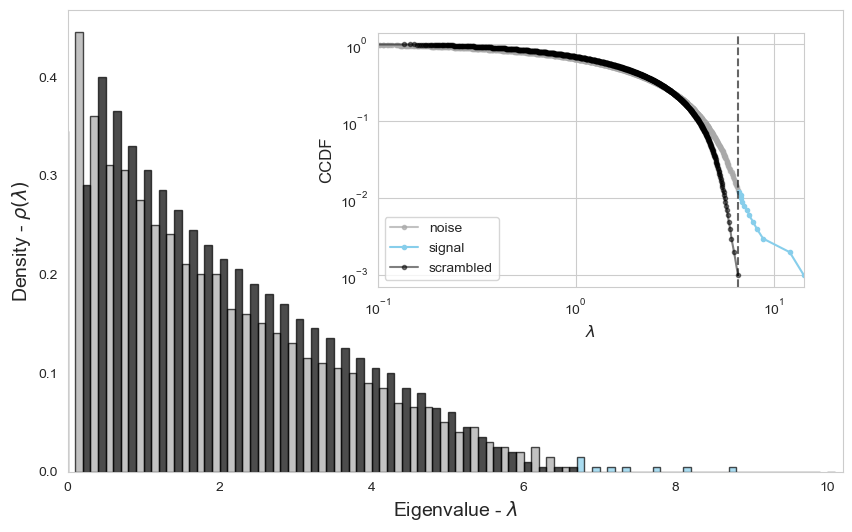

In [1]:
import numpy as np
import matplotlib.pyplot as plt
arr = np.load('ev_data/sample_13b_filtered.npy')
# 1. Generate data
data1 = arr[0,:]
data2 = arr[1,:]
data1 = data1[data1>0]
data2 = data2[data2>0]
alpha = 2
x1 = (1+np.sqrt(alpha))**2 #MP limit
x2 = np.max(data2)
bin_width = 0.2
all_data = np.concatenate([data1, data2])
bin_edges = np.arange(min(all_data), 10 + bin_width, bin_width)

fig, ax = plt.subplots(figsize=(10, 6))

# 2. Plot Dataset 1 (making bars slightly thinner than the bin width)
n1, bins1, patches1 = ax.hist(data1, bins=bin_edges, width=bin_width*0.5, align='left',
                              edgecolor='black',color='#d9d9d9', alpha=0.7, density=True)

# 3. Plot Dataset 2 (shifting its bin edges forward so they sit side-by-side/overlap)
n2, bins2, patches2 = ax.hist(data2, bins=bin_edges + (bin_width * 0.5), width=bin_width * 0.5,
                              edgecolor='black', color='black', alpha=0.7, label='Dataset 2',align='right', density=True)

# 4. Color Dataset 1 (Standard solid colors)
for patch in patches1:
    bin_x = patch.get_x()
    if bin_x < x2:
        patch.set_facecolor('darkgray')
    else:
        patch.set_facecolor('skyblue')


# 6. Add thresholds and layout elements
#ax.axvline(x1, color='k', linestyle='--', alpha=0.6)
#ax.axvline(x2, color='k', linestyle='--', alpha=0.6)

ax.set_xlabel(r"Eigenvalue - $\lambda$", fontsize=14)
ax.set_ylabel(r"Density - $\rho(\lambda)$", fontsize=14)
ax.set_yticks([0,0.1,0.2,0.3,0.4])
ax.grid(False)
ax.set_xlim([bin_edges[0], bin_edges[-1]+bin_width])
inset_ax = ax.inset_axes([0.4, 0.4, 0.55, 0.55])
data1 = np.sort(data1)
data2 = np.sort(data2)
p = len(data1)
cdf = np.arange(1, p + 1) / p
# 3. Calculate the CCDF (1 - CDF)
ccdf = 1 - cdf + (1/p)
noise_ind = data1<x2
inset_ax.loglog(data1[noise_ind], ccdf[noise_ind], marker='.', linestyle='-',color='darkgray', alpha=0.7, label = 'noise')
inset_ax.loglog(data1[np.invert(noise_ind)], ccdf[np.invert(noise_ind)], marker='.', linestyle='-',color='skyblue', label = 'signal')
inset_ax.loglog(data2, ccdf, marker='.', linestyle='-',color='black', alpha=0.5, label = 'scrambled')
inset_ax.set_xlim([0.1,np.max(data1)])
inset_ax.legend()
inset_ax.axvline(x2, color='k', linestyle='--', alpha=0.6)
inset_ax.set_xlabel(r"$\lambda$", fontsize=12)
inset_ax.set_ylabel(r"CCDF", fontsize=12)
plt.show()

Text(0, 0.5, 'CCDF')

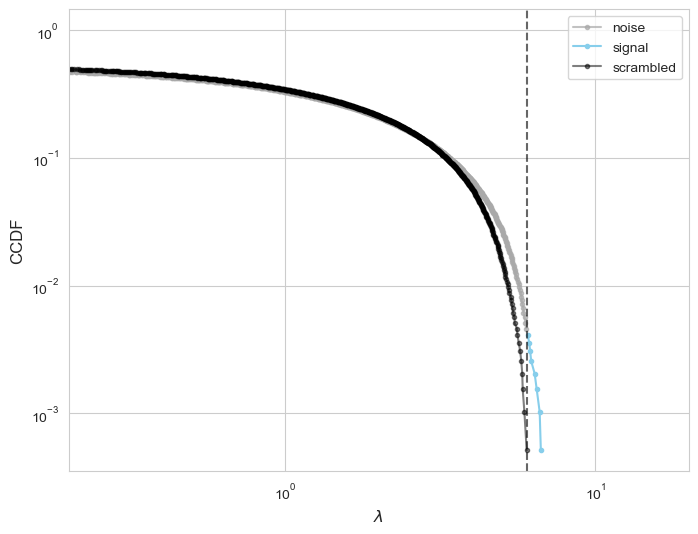

In [79]:
arr = np.load('ev_data/simulated_pcs_0.3.npy')
data1 = arr[0,:]
data2 = arr[1,:]
fig,ax = plt.subplots(figsize=(8, 6))
data1 = np.sort(data1)
data2 = np.sort(data2)
x2 = np.max(data2)
p = len(data1)
cdf = np.arange(1, p + 1) / p
# 3. Calculate the CCDF (1 - CDF)
ccdf = 1 - cdf + (1/p)
noise_ind = data1<x2
ax.loglog(data1[noise_ind], ccdf[noise_ind], marker='.', linestyle='-',color='darkgray', alpha=0.7, label = 'noise')
ax.loglog(data1[np.invert(noise_ind)], ccdf[np.invert(noise_ind)], marker='.', linestyle='-',color='skyblue', label = 'signal')
ax.loglog(data2, ccdf, marker='.', linestyle='-',color='black', alpha=0.5, label = 'scrambled')
ax.set_xlim([0.2,20])
ax.legend()
ax.axvline(x2, color='k', linestyle='--', alpha=0.6)
ax.set_xlabel(r"$\lambda$", fontsize=12)
ax.set_ylabel(r"CCDF", fontsize=12)

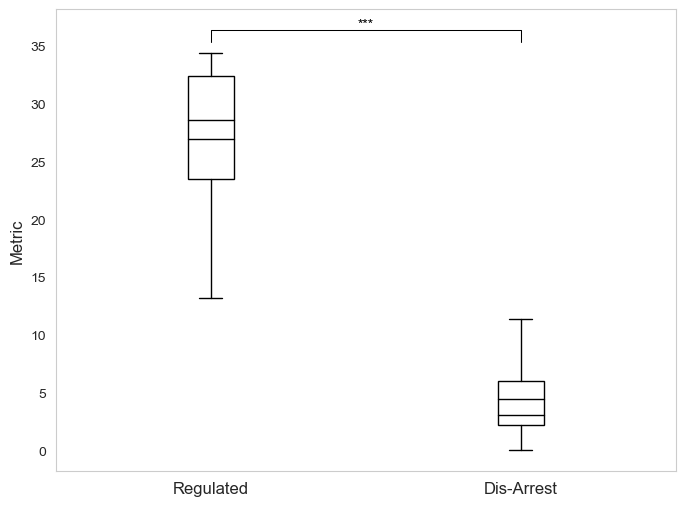

In [51]:
import pandas as pd
import scipy.stats as stats
def format_p(p):
    if p < 0.0001:
        return '****'
    elif p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'NS'
fsize = 12
fig,ax = plt.subplots(figsize=(8, 6))
path = r"C:\Users\owner\Documents\Projects\dysregulated-persistence\results\data_metrics\test8.csv"
data = pd.read_csv(path, index_col=0)
ranking_param = 'sum_denoised_ev'
# Sort values and compute rank
data['Rank'] = data[ranking_param].rank(method='min').astype(int)
# Split data into two groups based on labels
group1 = data[data['category'] == 'r'][ranking_param]
group0 = data[data['category'] == 'd'][ranking_param]
c = "k"
box = ax.boxplot([group1, group0], meanline=True, showmeans=True, patch_artist=True,
                 boxprops=dict(facecolor="None", color=c), whiskerprops=dict(color=c), capprops=dict(color=c),
                 flierprops=dict(markeredgecolor=c, markersize=2), medianprops=dict(color=c))
for element in ['boxes', 'whiskers', 'caps', 'medians']:
    for item in box[element]:
        item.set_linewidth(1)
for mean_line in box['means']:
    mean_line.set_linewidth(1)
    mean_line.set_color(c)
    mean_line.set_linestyle('solid')

ax.set_xticklabels(['Regulated', 'Dis-Arrest'], fontsize=fsize, rotation=0, ha='center')
#ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1])
#ax.set_ylim([0.2, 1])
#ax.set_yticklabels([0.2, 0.4, 0.6, 0.8, 1], fontsize=fsize - 2)
# add u-test results
u_stat, u_p = stats.mannwhitneyu(group1, group0)

# Define the level of significance
asterisks = format_p(u_p)
# Add significance annotation
x1, x2 = 1, 2  # x-coordinates of the box plots
y, h = max(max(group1), max(group0))+1, 1  # y-position and height of the annotation
ax.plot([x1, x1, x2, x2], [y, y + h, y + h, y], lw=.75, color='black')
ax.text((x1 + x2) * 0.5, y + h, asterisks, ha='center', va='bottom', color='black', fontsize=fsize - 2)
ax.set_ylabel(r'Metric', fontsize=fsize)
ax.grid(False)

Text(0, 0.5, '$\\sum_{\\lambda>\\lambda_{max}^{s}}{(\\lambda-\\lambda_{max}^{s})}$')

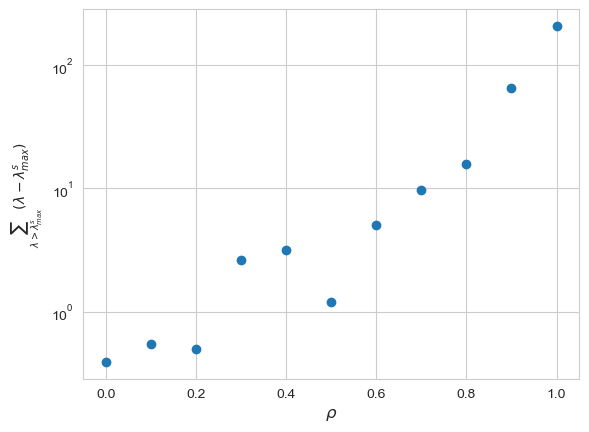

In [73]:
import os
import re
rho = []
sum_evs = []
dir_path = r"C:\Users\owner\Documents\Projects\dysregulated-persistence\scripts\ev_data"
for file in os.listdir(dir_path):
    match = re.search(r"(\d+\.?\d*)\.npy$", file)
    if match:
        # Extract the string representation of the number
        number_str = match.group(1)

        # Convert it to a float (or int if it doesn't have a decimal)
        number = float(number_str) if '.' in number_str else int(number_str)
        rho.append(number)
        arr = np.load(os.path.join(dir_path,file))
        pcs = arr[0,:]
        pcs1 = arr[1,:]
        sum_evs.append(np.sum(pcs[pcs>np.max(pcs1)]-np.max(pcs1)))
plt.scatter(rho, sum_evs)
plt.yscale('log')
plt.xlabel(r"$\rho$", fontsize=fsize)
plt.ylabel(r"$\sum_{\lambda>\lambda_{max}^{s}}{(\lambda-\lambda_{max}^{s})}$")